# Advanced Image Generation Techniques with Amazon Nova
## Mastering Generative AI: From Fundamentals to Advanced Applications

This notebook demonstrates advanced image generation capabilities using Amazon Nova Canvas through the AWS Bedrock API. We'll explore:

- Inpainting (selective image editing)
- Outpainting (extending images beyond their borders)
- Automated editing without image mask

### Setup and Configuration

### Prerequisites
- AWS account with access to Amazon Bedrock service
- AWS credentials configured properly

```

Install the necessary libraries and set up the environment.

In [6]:
!uv add --quiet boto3 pillow requests ipywidgets matplotlib

In [ ]:
import boto3
import base64
import json
import io
import time
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os
from IPython.display import display, HTML


os.environ['AWS_ACCESS_KEY_ID'] = 'YOUR_KEY'
os.environ['AWS_SECRET_ACCESS_KEY'] = 'YOUR_KEY'

os.environ['AWS_REGION'] = 'us-east-1' 


region="us-east-1"
bedrock_runtime = boto3.client('bedrock-runtime', region_name=region)


# Helper Functions
import base64
from PIL import Image, ImageOps
import io

def encode_image(image_path, invert=False):
    """
    Encode image to base64 string with option to invert the image.
    
    Args:
        image_path (str): Path to the image file
        invert (bool, optional): Whether to invert the image. Defaults to False.
    
    Returns:
        str: Base64 encoded image
    """
    if invert:
        # Open the image with PIL
        with Image.open(image_path) as img:
            # Invert the image
            inverted_img = ImageOps.invert(img.convert('RGB'))
            
            # Save to bytes buffer instead of file
            buffer = io.BytesIO()
            inverted_img.save(buffer, format=img.format or 'PNG')
            buffer.seek(0)
            
            # Encode the bytes
            return base64.b64encode(buffer.getvalue()).decode('utf-8')
    else:
        # Original functionality for non-inverted images
        with open(image_path, "rb") as image_file:
            return base64.b64encode(image_file.read()).decode('utf-8')

def decode_image(base64_string):
    """Decode base64 string to PIL Image"""
    image_data = base64.b64decode(base64_string)
    return Image.open(io.BytesIO(image_data))

def display_images(image_list, titles=None, figsize=(15, 15), columns=3):
    """Display multiple images in a grid"""
    rows = len(image_list) // columns + (1 if len(image_list) % columns > 0 else 0)
    fig, axes = plt.subplots(rows, columns, figsize=figsize)
    axes = axes.flatten()
    
    for i, img in enumerate(image_list):
        if i < len(image_list):
            axes[i].imshow(img)
            if titles and i < len(titles):
                axes[i].set_title(titles[i])
            axes[i].axis('off')
    
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

def invoke_nova_canvas(payload):
    """Invoke Amazon Nova Canvas with appropriate timeout"""
    response = bedrock_runtime.invoke_model(
        modelId="amazon.nova-canvas-v1:0",
        body=json.dumps(payload),
        contentType="application/json",
        accept="application/json",
    )
    
    body = json.loads(response.get('body').read().decode('utf-8'))
    return body

## 1. Inpainting: Selective Image Editing

Inpainting allows you to modify specific portions of an image while preserving the rest. This technique is valuable for:
- Removing unwanted elements
- Adding new features to existing images
- Fixing damaged or corrupted areas

Let's explore both automatic masking (using natural language) and manual masking approaches:

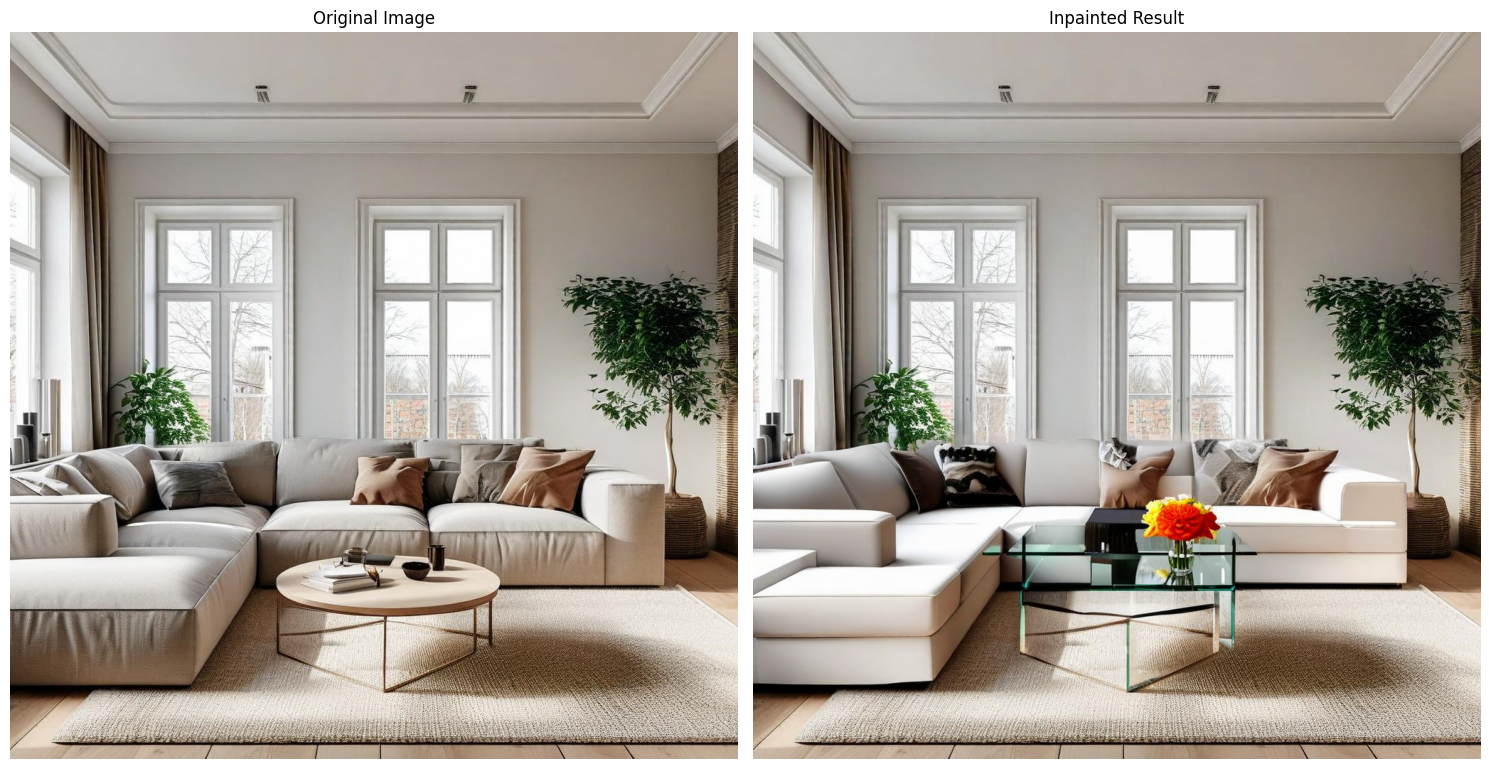

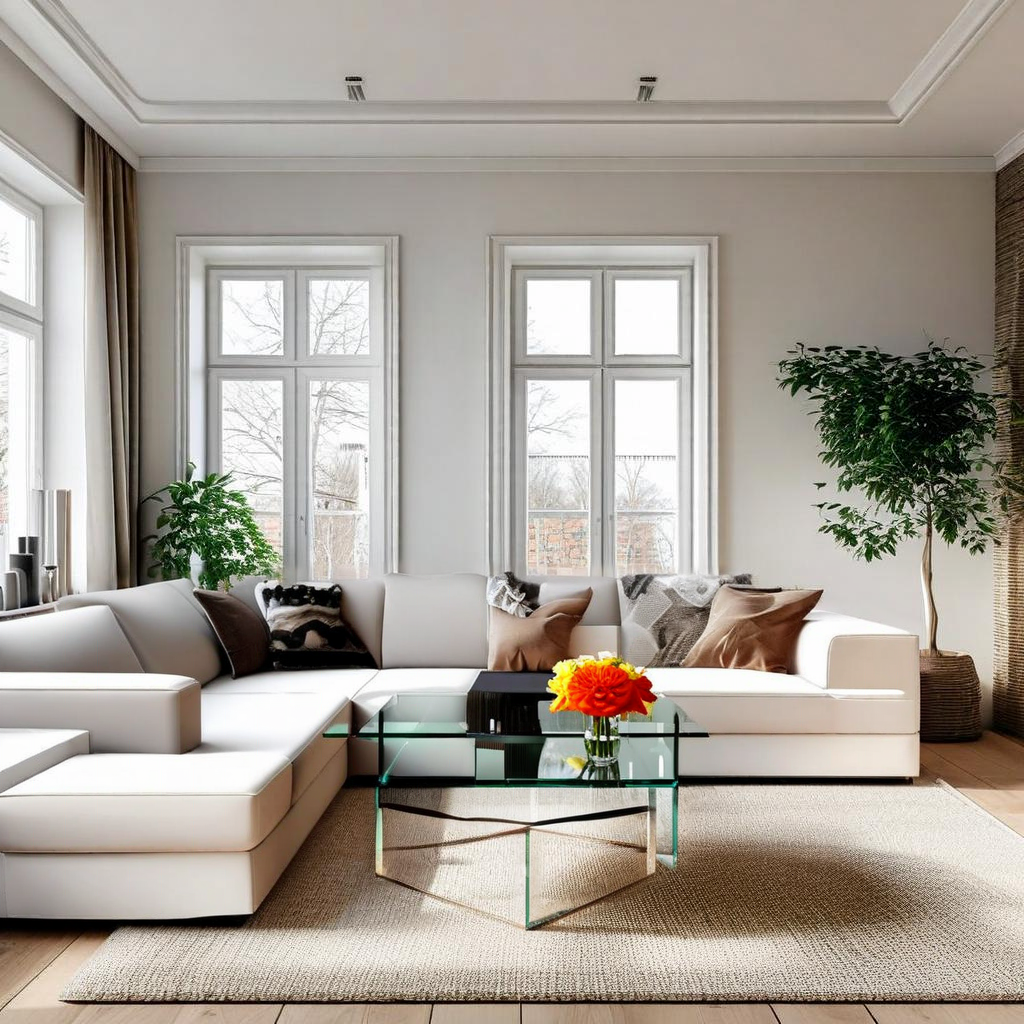

In [9]:
# Example: Inpainting with a text-based mask
def inpaint_with_text_mask(input_image_path, mask_prompt, inpaint_prompt, negative_prompt=""):
    """
    Inpainting using text to define the mask area
    
    Parameters:
    - input_image_path: Path to the original image
    - mask_prompt: Text describing which part of the image to mask
    - inpaint_prompt: Text describing what to generate in the masked area
    - negative_prompt: Optional prompt for what to avoid generating
    """
    base64_image = encode_image(input_image_path)
    
    payload = {
        "taskType": "INPAINTING",
        "inPaintingParams": {
            "image": base64_image,
            "maskPrompt": mask_prompt,
            "text": inpaint_prompt,
            "negativeText": negative_prompt
        },
        "imageGenerationConfig": {
            "numberOfImages": 1,
            "quality": "premium",
            "cfgScale": 8.0
        }
    }
    
    response = invoke_nova_canvas(payload)
    
    # Display original and result
    original_image = Image.open(input_image_path)
    result_image = decode_image(response["images"][0])
    
    display_images([original_image, result_image], 
                   titles=["Original Image", "Inpainted Result"], 
                   columns=2)
    
    return result_image

# Example usage
inpaint_with_text_mask(
 "example_images/living_room.jpg",
 "the coffee table",
 "a modern glass coffee table with a vase of fresh flowers",
 "unrealistic proportions"
)

Now let's implement manual masking, where we provide a separate mask image:

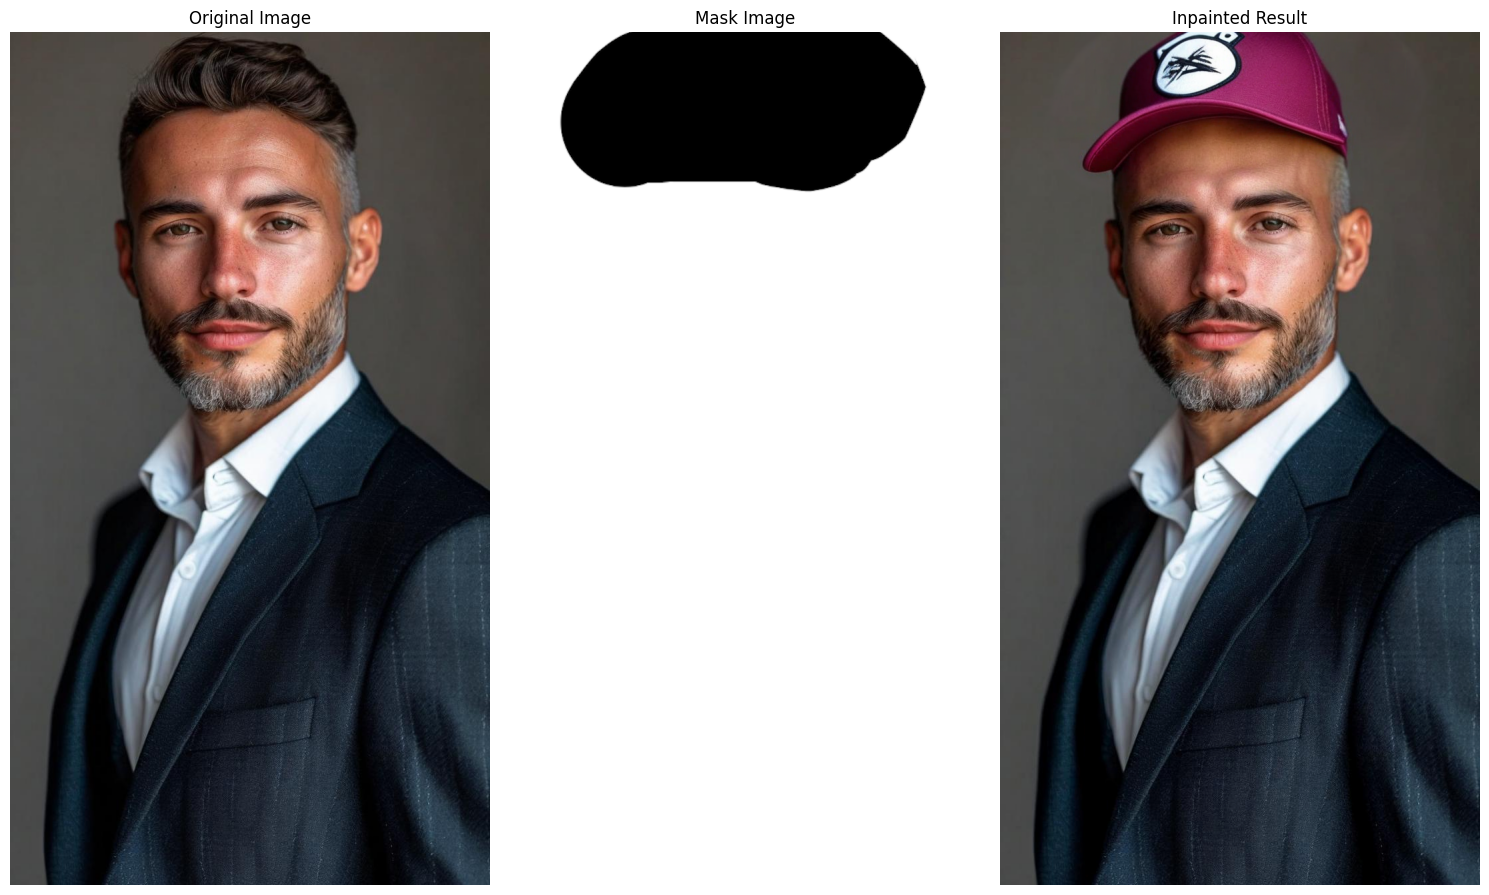

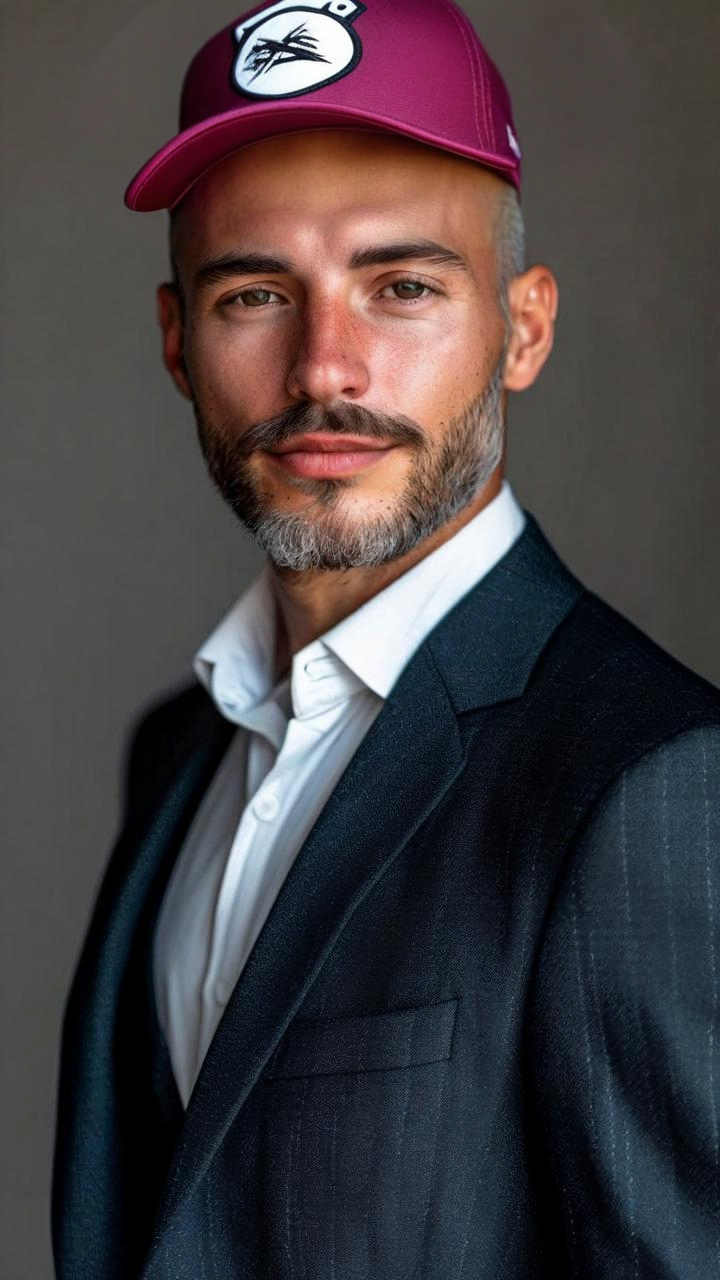

In [10]:
def inpaint_with_image_mask(input_image_path, mask_image_path, inpaint_prompt, negative_prompt=""):
    """
    Inpainting using a separate mask image
    
    Parameters:
    - input_image_path: Path to the original image
    - mask_image_path: Path to the mask image (black=masked area, white=preserved area)
    - inpaint_prompt: Text describing what to generate in the masked area
    - negative_prompt: Optional prompt for what to avoid generating
    """
    base64_image = encode_image(input_image_path)
    base64_mask = encode_image(mask_image_path)
    
    payload = {
        "taskType": "INPAINTING",
        "inPaintingParams": {
            "image": base64_image,
            "maskImage": base64_mask,
            "text": inpaint_prompt,
            "negativeText": negative_prompt
        },
        "imageGenerationConfig": {
            "numberOfImages": 1,
            "quality": "premium",
            "cfgScale": 8.0
        }
    }
    
    response = invoke_nova_canvas(payload)
    
    # Display original, mask, and result
    original_image = Image.open(input_image_path)
    mask_image = Image.open(mask_image_path)
    result_image = decode_image(response["images"][0])
    
    display_images([original_image, mask_image, result_image], 
                   titles=["Original Image", "Mask Image", "Inpainted Result"], 
                   columns=3)
    
    return result_image

# Example usage
inpaint_with_image_mask(
     "example_images/portrait.jpg",
     "example_images/portrait_mask_v2.png",
     "baseball cap, photorealistic",
     "unnatural lighting"
)

## 2. Outpainting: Extending Images Beyond Their Boundaries

Outpainting allows you to expand images beyond their original boundaries, creating a seamless extension of the scene:

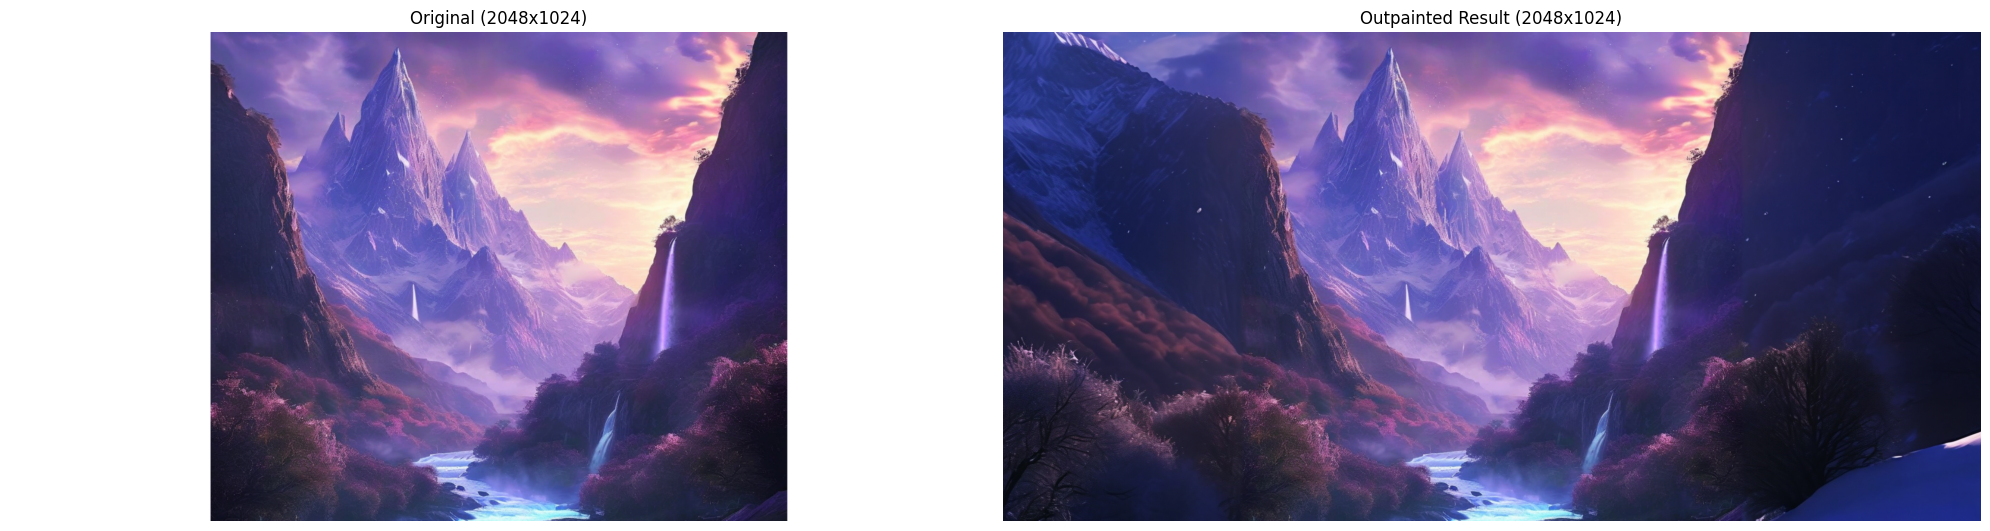

In [11]:
def outpaint_image(input_image_path, mask, prompt, width=2048, height=1024, negative_prompt=""):
    """
    Outpainting to extend an image beyond its original boundaries
    
    Parameters:
    - input_image_path: Path to the original image
    - prompt: Text describing the extended scene
    - width: Desired width of the output image
    - height: Desired height of the output image
    - negative_prompt: Optional prompt for what to avoid generating
    """
    base64_image = encode_image(input_image_path)
    base64_mask = encode_image(mask, True)
    
    # Get original image dimensions
    original_image = Image.open(input_image_path)
    orig_width, orig_height = original_image.size
    
    payload = {
        "taskType": "OUTPAINTING",
        "outPaintingParams": {
            "maskImage": base64_mask,
            "image": base64_image,
            "outPaintingMode": "DEFAULT",
            "negativeText": negative_prompt,
            "text": prompt
        },
        "imageGenerationConfig": {
            "numberOfImages": 1,
            "quality": "premium",
            "width": width,
            "height": height,
            "cfgScale": 7.5
        }
    }
    
    response = invoke_nova_canvas(payload)
    
    # Display original and extended result
    result_image = decode_image(response["images"][0])
    
    # Create a comparison image showing the extension
    fig, ax = plt.subplots(1, 2, figsize=(20, 10))
    ax[0].imshow(original_image)
    ax[0].set_title(f"Original ({orig_width}x{orig_height})")
    ax[0].axis('off')
    
    ax[1].imshow(result_image)
    ax[1].set_title(f"Outpainted Result ({width}x{height})")
    ax[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return result_image

# Example usage
outpainted_image = outpaint_image(
    "example_images/landscape.png",
    "example_images/landscape_outpainting.png",
    "snow mountains",
    width=2048,
    height=1024,
    negative_prompt="distorted perspective, unnatural boundaries"
)